In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, cohen_kappa_score
from tqdm import tqdm
# import timm
import random
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(seed=42)


In [2]:
IMG_SIZE = 448
if_multi_task = True
if_bottleneck = False
data_dir = "../data/aptos-2019/"
# 加载保存的最佳权重
model_path = "/home/gsintern/gs-lts/Template/d2l-main/aptos/exp_effb4_regression/multi-task_exp4-0.8484/best_model_reg.pth" 
head_model_path = "/home/gsintern/gs-lts/Template/d2l-main/aptos/exp_effb4_regression/multi-task_exp4-0.8484/classify_head/exp2-0.8484/best_mlp_head.pth"
os.environ['CUDA_VISIBLE_DEVICES'] = '0, 1'
devices = [torch.device(f'cuda:{i}') for i in range(torch.cuda.device_count())]
# devices = ['cpu']

In [3]:
class DRTestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.has_labels = 'diagnosis' in df.columns

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['id_code']
        img_path = row['img_path']
        label = row['diagnosis']
        
        # 健壮性检查
        if not os.path.exists(img_path):
            img_path = img_path.replace(".png", ".jpg")
            if not os.path.exists(img_path):
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            else:
                image = Image.open(img_path).convert('RGB')
        else:
            image = Image.open(img_path).convert('RGB')

        if self.transform and not isinstance(image, torch.Tensor):
            image = self.transform(image)
        
        # 如果有标签则返回标签，否则返回 -1
        label = row['diagnosis'] if self.has_labels else -1
        return image, label, img_name

# 加载测试集 CSV
test_csv_path = os.path.join(data_dir, "test.csv")
val_csv_path = os.path.join(data_dir, "valid.csv")
test_df = pd.read_csv(test_csv_path)
val_df = pd.read_csv(val_csv_path)
test_image_dir = os.path.join(data_dir, "test_images")
val_image_dir = os.path.join(data_dir, "val_images")
# 为每个数据集构造完整的图片路径
test_df['img_path'] = test_df['id_code'].apply(lambda x: os.path.join(test_image_dir, f"{x}.png"))
val_df['img_path'] = val_df['id_code'].apply(lambda x: os.path.join(val_image_dir, f"{x}.png"))

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
combined_test_df = pd.concat([test_df, val_df], axis=0).reset_index(drop=True)
print(f"合并完成：测试集({len(test_df)}) + 验证集({len(val_df)}) = 总计 {len(combined_test_df)} 样本")
# 定义推理 DataLoader
test_loader = DataLoader(
    DRTestDataset(combined_test_df, test_tf), 
    batch_size=32, 
    shuffle=False, 
    num_workers=8
)

合并完成：测试集(366) + 验证集(366) = 总计 732 样本


In [4]:
class FullClassifier(nn.Module):
    def __init__(self, backbone, head, if_multi_task=False):
        super(FullClassifier, self).__init__()
        self.feature_extractor = backbone
        self.backbone_head = backbone.classifier 
        self.feature_extractor.classifier = nn.Identity()
        self.mlp_head = head
        self.if_multi_task = if_multi_task

    def forward(self, x):
        feat = self.feature_extractor(x)
        
        # 1. 获取骨干网络的原始输出
        backbone_out = self.backbone_head(feat) 
        
        if self.if_multi_task:
            # 多任务情况：输出 6 列 (1回归 + 5分类)
            reg_out = backbone_out[:, 0:1]
            bb_cls_out = backbone_out[:, 1:6]
        else:
            # 单任务情况：输出 1 列 (只有回归)
            reg_out = backbone_out[:, 0:1]
            bb_cls_out = None # 没有骨干自带分类
        
        # 2. 获取独立的 MLP 分类头输出 (始终为 5 列)
        mlp_cls_out = self.mlp_head(feat) 
        
        # 3. 动态拼接输出
        if bb_cls_out is not None:
            # 返回 11 列: [reg, bb_cls, mlp_cls]
            return torch.cat([reg_out, bb_cls_out, mlp_cls_out], dim=1)
        else:
            # 返回 6 列: [reg, mlp_cls]
            return torch.cat([reg_out, mlp_cls_out], dim=1)

In [8]:
def create_effb4_regressor():
    weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1
    model = models.efficientnet_b4(weights=weights)
    in_features = model.classifier[1].in_features
    if if_multi_task:
        num_out = 6
    else:
        num_out = 1
    if if_bottleneck:
        # TODO:引入特征瓶颈层
        # 在 classifier 之前增加一个低维线性层（256 维），并施加 正交约束 或 LayerNorm。
        model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.LayerNorm(256), # 关键：将特征约束在超球面上，有利于线性插值
        nn.ReLU(),
        nn.Linear(256, num_out) # 1回归 + 5分类
        )
    else:
        model.classifier[1] = nn.Linear(in_features, num_out)
    return model
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.LeakyReLU(0.2), # LeakyReLU 避免神经元死亡
            nn.Dropout(0.3),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.relu(x + self.block(x)) # 残差连接

class AdvancedMLP(nn.Module):
    def __init__(self, in_features=1792, num_classes=5):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2)
        )
        # 两个残差块
        self.res1 = ResBlock(1024)
        self.res2 = ResBlock(1024)
        
        self.classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_classes)
        )
        # # TODO:引入特征瓶颈层
        # self.classifier = nn.Sequential(
        # nn.Linear(1024, 256),
        # nn.LayerNorm(256), # 关键：将特征约束在超球面上，有利于线性插值
        # nn.ReLU(),
        # nn.Linear(256, num_classes) # 5分类
        # )


    def forward(self, x):
        x = self.input_layer(x)
        x = self.res1(x)
        x = self.res2(x)
        return self.classifier(x)
    
# 实例化模型并移动到指定 GPU
device = devices[0]
model = create_effb4_regressor().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
head_model =  AdvancedMLP().to(device)
head_model.load_state_dict(torch.load(head_model_path, map_location=device))
# 实例化模型时传入参数
final_model = FullClassifier(model, head_model, if_multi_task=if_multi_task).to(device)
final_model.eval()


/tmp/ipykernel_2471868/2922195001.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
/tmp/ipykernel_2471

FullClassifier(
  (feature_extractor): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
              (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
       

In [17]:
# 权重矩阵 [模型数(3), 类别数(5)]
# 按 Precision 作为权重
weight_matrix = np.array([
    [0.9891, 0.5373, 0.6682, 0.1667, 0.5714], # 1. Regression (回归分支)
    [0.9813, 0.5875, 0.7171, 0.4074, 0.7174], # 2. Backbone Head (骨干头)
    [0.9866, 0.6667, 0.7249, 0.5000, 0.7619]  # 3. Advanced MLP (MLP头)
])

In [18]:
import pickle
# 加载最佳阈值
threshold_path = os.path.join(os.path.dirname(model_path), "best_grid_thresholds.pkl")
with open(threshold_path, "rb") as f:
    best_thresholds = pickle.load(f)

# 动态加权投票
def dynamic_ensemble(reg_digitized, prob_bb, prob_mlp, weight_matrix):
    """
    reg_digitized: [batch] 整数标签
    prob_bb: [batch, 5] 概率
    prob_mlp: [batch, 5] 概率
    """
    batch_size = len(reg_digitized)
    final_probs = np.zeros((batch_size, 5))
    
    # 将回归结果转为 one-hot 概率分布以方便融合
    prob_reg = np.eye(5)[reg_digitized] 
    
    # 逐样本动态计算
    for i in range(batch_size):
        # 1. 获取三个模型初步预测的类别
        pred_reg = reg_digitized[i]
        pred_bb = prob_bb[i].argmax()
        pred_mlp = prob_mlp[i].argmax()
        
        # 2. 根据各自预测的类别，从映射表提取权重
        w_reg = weight_matrix[0, pred_reg]
        w_bb = weight_matrix[1, pred_bb]
        w_mlp = weight_matrix[2, pred_mlp]
        
        # 归一化权重
        total_w = w_reg + w_bb + w_mlp
        w_reg, w_bb, w_mlp = w_reg/total_w, w_bb/total_w, w_mlp/total_w
        
        # 3. 加权融合概率
        final_probs[i] = w_reg * prob_reg[i] + w_bb * prob_bb[i] + w_mlp * prob_mlp[i]
        
    return final_probs.argmax(axis=1)

In [27]:
import numpy as np
from sklearn.metrics import accuracy_score, cohen_kappa_score
from tqdm import tqdm

all_ids, all_targets = [], []
all_reg_preds = []       # 分支1: 数字化后的回归
all_bb_cls_preds = []    # 分支2: 骨干自带分类
all_mlp_cls_preds = []   # 分支3: 独立 MLP 分类
all_ensemble_preds = []  # ★ 最终集成结果

print(f"正在执行集成推理 (含 TTA & 多分支投票)...")

with torch.no_grad():
    for imgs, labels, ids in tqdm(test_loader):
        imgs = imgs.to(device)
        
        # 1. 水平翻转 TTA
        out_orig = final_model(imgs)
        out_flip = final_model(torch.flip(imgs, dims=[3]))
        outputs = (out_orig + out_flip) / 2.0
        
        # --- 分支解析 ---
        # A. 回归值处理
        reg_val = outputs[:, 0].cpu().numpy()
        reg_digitized = np.digitize(reg_val, best_thresholds).astype(int)
        
        # B. 提取分类概率
        prob_bb = torch.softmax(outputs[:, 1:6], dim=1).cpu().numpy()
        prob_mlp = torch.softmax(outputs[:, 6:11], dim=1).cpu().numpy()
        
        # --- 投票与集成策略 ---
        # 策略 1: 分类头软集成 (权重分配参考验证集表现 0.89 vs 0.87)
        soft_cls_probs = 0.6 * prob_bb + 0.4 * prob_mlp
        cls_ensemble_label = soft_cls_probs.argmax(axis=1)
        
        # 策略 2: 最终集成 (结合回归分支与分类分支)
        # 使用 0.4 * 回归类别 + 0.6 * 分类类别，再取整，能获得更好的 Kappa
        # final_preds = np.round(0.4 * reg_digitized + 0.6 * cls_ensemble_label).astype(int)
        # final_preds = np.clip(final_preds, 0, 4)
        final_preds = dynamic_ensemble(reg_digitized, prob_bb, prob_mlp, weight_matrix)

        # 收集结果
        all_ids.extend(ids)
        all_reg_preds.extend(reg_digitized)
        all_bb_cls_preds.extend(prob_bb.argmax(axis=1))
        all_mlp_cls_preds.extend(prob_mlp.argmax(axis=1))
        all_ensemble_preds.extend(final_preds)
        all_targets.extend(labels.numpy())

actual = np.array(all_targets)

# --- 打印最终对比报告 ---
def print_res(name, preds):
    acc = accuracy_score(actual, preds)
    kappa = cohen_kappa_score(actual, preds, weights='quadratic')
    print(f"{name:<18} | Acc: {acc:.4f} | Kappa: {kappa:.4f}")

if len(actual) > 0:
    print("\n" + "="*60)
    print(f"测试集评估报告 (n={len(actual)}):")
    print_res("1. 纯回归(最佳阈值)", all_reg_preds)
    print_res("2. 骨干分类头", all_bb_cls_preds)
    print_res("3. 独立 MLP 分类头", all_mlp_cls_preds)
    print("-" * 60)
    print_res("★ 多分支集成预测", all_ensemble_preds)
    print("="*60)

正在执行集成推理 (含 TTA & 多分支投票)...


100%|██████████| 23/23 [00:12<00:00,  1.85it/s]


测试集评估报告 (n=732):
1. 纯回归(最佳阈值)       | Acc: 0.7992 | Kappa: 0.8917
2. 骨干分类头           | Acc: 0.8292 | Kappa: 0.8970
3. 独立 MLP 分类头      | Acc: 0.8456 | Kappa: 0.8968
------------------------------------------------------------
★ 多分支集成预测          | Acc: 0.8361 | Kappa: 0.8998



 详细分析报告: 1. Regression (Optimized)
              precision    recall  f1-score   support

     Class 0     0.9891    0.9784    0.9837       371
     Class 1     0.5373    0.5143    0.5255        70
     Class 2     0.6682    0.7801    0.7198       191
     Class 3     0.1667    0.0513    0.0784        39
     Class 4     0.5714    0.5902    0.5806        61

    accuracy                         0.8005       732
   macro avg     0.5865    0.5829    0.5776       732
weighted avg     0.7835    0.8005    0.7892       732



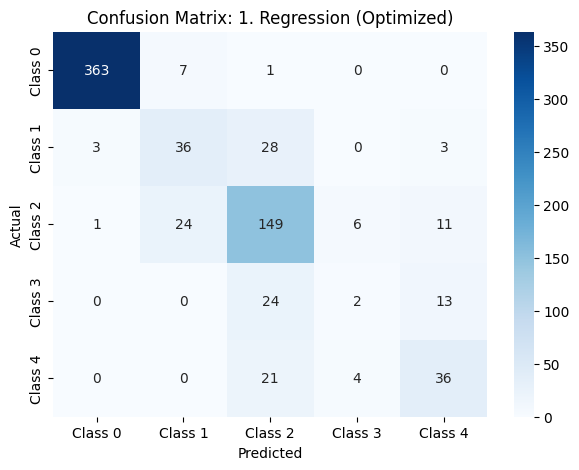


 详细分析报告: 2. Backbone Head (BB-Cls)
              precision    recall  f1-score   support

     Class 0     0.9838    0.9838    0.9838       371
     Class 1     0.5750    0.6571    0.6133        70
     Class 2     0.7246    0.7853    0.7538       191
     Class 3     0.4815    0.3333    0.3939        39
     Class 4     0.7021    0.5410    0.6111        61

    accuracy                         0.8292       732
   macro avg     0.6934    0.6601    0.6712       732
weighted avg     0.8269    0.8292    0.8259       732



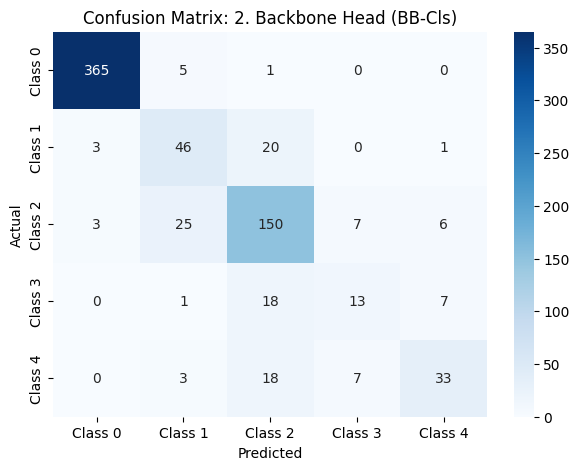


 详细分析报告: 3. Advanced MLP (MLP-Cls)
              precision    recall  f1-score   support

     Class 0     0.9839    0.9892    0.9866       371
     Class 1     0.6825    0.6143    0.6466        70
     Class 2     0.7179    0.8796    0.7906       191
     Class 3     0.5000    0.2564    0.3390        39
     Class 4     0.7381    0.5082    0.6019        61

    accuracy                         0.8456       732
   macro avg     0.7245    0.6495    0.6729       732
weighted avg     0.8394    0.8456    0.8364       732



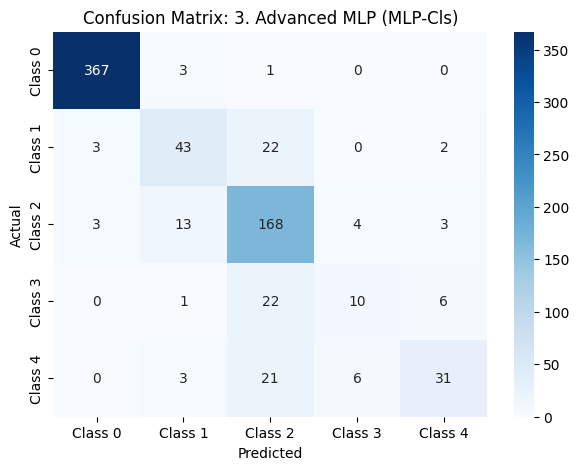


 详细分析报告: ★ Final Ensemble
              precision    recall  f1-score   support

     Class 0     0.9865    0.9865    0.9865       371
     Class 1     0.6349    0.5714    0.6015        70
     Class 2     0.7009    0.8586    0.7718       191
     Class 3     0.5333    0.2051    0.2963        39
     Class 4     0.6939    0.5574    0.6182        61

    accuracy                         0.8361       732
   macro avg     0.7099    0.6358    0.6549       732
weighted avg     0.8298    0.8361    0.8262       732



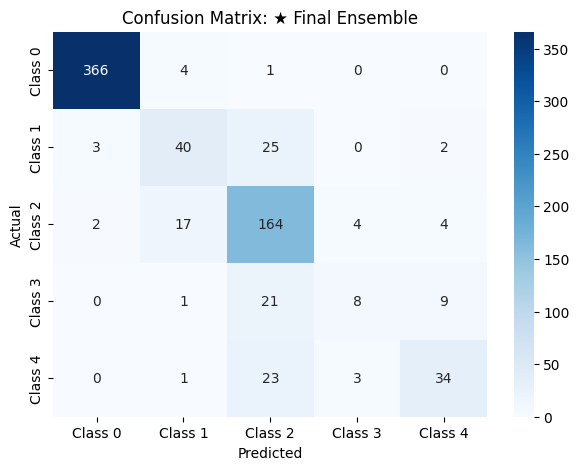

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 准备数据：确保全部为整数类别 ---
# 强制转换真实标签为整数
y_true_int = np.array(all_targets).astype(int)

# 确保回归分支使用的是处理后的 final_reg_labels
heads_data = {
    "1. Regression (Optimized)": np.array(final_reg_labels).astype(int),
    "2. Backbone Head (BB-Cls)": np.array(all_bb_cls_preds).astype(int),
    "3. Advanced MLP (MLP-Cls)": np.array(all_mlp_cls_preds).astype(int),
    "★ Final Ensemble": np.array(all_ensemble_preds).astype(int) # 如果你跑了集成逻辑
}

def analyze_heads_fixed(heads_dict, y_true):
    # 过滤掉不存在的类别，确保 target_names 匹配
    unique_labels = np.unique(y_true)
    class_names = [f"Class {i}" for i in unique_labels]
    
    for name, y_pred in heads_dict.items():
        # 检查长度是否匹配
        if len(y_pred) != len(y_true):
            print(f"警告: {name} 的预测样本数与真实标签不符，跳过。")
            continue
            
        print(f"\n" + "="*40)
        print(f" 详细分析报告: {name}")
        print("="*40)
        
        # 使用 digits=4 观察细微差异
        print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
        
        # 绘制混淆矩阵
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix: {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

# --- 2. 执行分析 ---
analyze_heads_fixed(heads_data, y_true_int)

In [29]:
all_ids, all_targets = [], []
all_reg_preds = []      # 分支1: 回归原始值
all_bb_cls_preds = []   # 分支2: 骨干自带分类 (仅 if_multi_task=True)
all_mlp_cls_preds = []  # 分支3: 独立 MLP 分类头

print(f"正在执行推理 (模式: {'多任务骨干' if if_multi_task else '单任务骨干'})...")

with torch.no_grad():
    for imgs, labels, ids in tqdm(test_loader):
        imgs = imgs.to(device)
        outputs = final_model(imgs)
        
        # --- 核心切片解析逻辑 ---
        reg_val = outputs[:, 0].cpu().numpy()
        
        if if_multi_task:
            # 多任务模式: outputs 总宽 11
            bb_cls = torch.softmax(outputs[:, 1:6], dim=1).argmax(dim=1).cpu().numpy()
            mlp_cls = torch.softmax(outputs[:, 6:11], dim=1).argmax(dim=1).cpu().numpy()
            all_bb_cls_preds.extend(bb_cls)
        else:
            # 单任务模式: outputs 总宽 6
            mlp_cls = torch.softmax(outputs[:, 1:6], dim=1).argmax(dim=1).cpu().numpy()
        
        all_ids.extend(ids)
        all_reg_preds.extend(reg_val)
        all_mlp_cls_preds.extend(mlp_cls)
        all_targets.extend(labels.numpy())

# 后处理
# final_reg_labels = np.round(np.clip(all_reg_preds, 0, 4)).astype(int)
final_reg_labels = np.digitize(all_reg_preds, best_thresholds).astype(int)
actual = np.array(all_targets)

# --- 指标对比打印 ---
if test_df.get('diagnosis') is not None:
    print("\n" + "="*50)
    print(f"测试集评估结果 (n={len(actual)}):")
    print(f"1. 回归取整分支    | Acc: {accuracy_score(actual, final_reg_labels):.4f} | Kappa: {cohen_kappa_score(actual, final_reg_labels, weights='quadratic'):.4f}")
    
    if if_multi_task:
        print(f"2. 骨干自带分类头  | Acc: {accuracy_score(actual, all_bb_cls_preds):.4f} | Kappa: {cohen_kappa_score(actual, all_bb_cls_preds, weights='quadratic'):.4f}")
    
    print(f"3. 独立 MLP 分类头 | Acc: {accuracy_score(actual, all_mlp_cls_preds):.4f} | Kappa: {cohen_kappa_score(actual, all_mlp_cls_preds, weights='quadratic'):.4f}")
    print("="*50)

正在执行推理 (模式: 多任务骨干)...


100%|██████████| 23/23 [00:11<00:00,  1.95it/s]



测试集评估结果 (n=732):
1. 回归取整分支    | Acc: 0.8005 | Kappa: 0.8893
2. 骨干自带分类头  | Acc: 0.8265 | Kappa: 0.8959
3. 独立 MLP 分类头 | Acc: 0.8484 | Kappa: 0.9017


In [30]:
print(combined_test_df['diagnosis'].value_counts().sort_index())

diagnosis
0    371
1     70
2    191
3     39
4     61
Name: count, dtype: int64
